In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from typing import Dict, List, Tuple
from data_loading import *
from loss_funcs import *

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}") # I have a 3090
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")
# ── SARIMAX-specific imports ────────────────────────────────────
import itertools
import time
import os
from collections import defaultdict, Counter

import mlflow
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

N_CORES = max(1, (os.cpu_count() or 4) - 1)   # leave one core free for the OS
print(f"statsmodels SARIMAX ready, mlflow {mlflow.__version__}, n_cores={N_CORES}")

PyTorch version  : 2.10.0
CUDA available   : False
statsmodels SARIMAX ready, mlflow 3.11.1, n_cores=7


In [2]:
weather_cols_all = ['temperature_2m',
       'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m',
       'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure',
       'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance']

other_cols = [ # these are not static
    'dam_price', 'buy_bm_price', 'sell_bm_price',
    'max_power', 'max_solar', 'max_ev'
]

cat_columns = [
    'eic_code', 'dso_desc', 'station_type', 'oblast',
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

static_cols = [
    'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast'
]

calendar_cols = [
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

time_cols = ['datetime', 'time_idx']

FUTURE_REALS = weather_cols_all + calendar_cols + static_cols + other_cols
print(f"y col is: {Y_COL}, group col is: {GROUP_COL}\n"
      f"features: {FUTURE_REALS}")

y col is: sum_of_kWh, group col is: eic_code
features: ['temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'Month', 'Day', 'Hour', 'day_of_week', 'season', 'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast', 'dam_price', 'buy_bm_price', 'sell_bm_price', 'max_power', 'max_solar', 'max_ev']


In [3]:
# this data has a data column and categorical columns are kept intact and will need to be handled.
# "time_idx" is already built in train, val and test and is continuous through them
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)
train = train[train["datetime"] >= "2025-06-01"].copy()

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
Loading val   …
Loading test  …
train: (284400, 38)
val : (293880, 38)
test: (295430, 38)


In [4]:
# # If a model cant handle categorical columns natively, or through embedings use this data
# # It has no datetime column and all columns are numeric, as all cat column were ohe
# # GROUP_COL is the only exception, and is not ohe. Ohe it before training
# print("Loading train …")
# train = load_and_prepare(TRAIN_PATH_OHE)
#
# print("Loading val   …")
# val = load_and_prepare(VAL_PATH_OHE)
#
# print("Loading test  …")
# test = load_and_prepare(TEST_PATH_OHE)
#
# print(f"train: {train.shape}")
# print(f"val  : {val.shape}")
# print(f"test : {test.shape}")

In [5]:
# this cell samples locations, I'll use it if training takes too long, otherwise don't touch it

TARGET_STATIONS = 395

station_stats = (
    train.groupby(GROUP_COL)
    .agg(rows=(Y_COL, "count"))
    .reset_index()
    .sort_values("rows", ascending=False)
)

sampled_stations = station_stats.sample(
    n=TARGET_STATIONS, random_state=42
)[GROUP_COL].values

print(f"Stations: {len(sampled_stations)}")

train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 395
Train rows : 284,400
Val rows   : 293,880
Test rows  : 295,430


In [6]:
training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617


In [7]:
# ────────────────────────────────────────────────────────────────
# SARIMAX configuration (optimised for runtime)
#
# SARIMAX = Seasonal ARIMA with eXogenous regressors.
#   Non-seasonal order : (p, d, q)
#   Seasonal order     : (P, D, Q, s), s=24 = daily for hourly data
#
# Speed strategy (combines 4 levers):
#   1. CLUSTER stations by load profile and grid-search ONE representative per
#      cluster — reuse the chosen order on every station in that cluster.
#      We still fit a separate SARIMAX per station, never cross-station mixing.
#   2. FOCUSED grid: d=1, D=1 fixed (right for non-stationary hourly load with
#      daily seasonality), small p/q/P/Q ranges → ~10 candidates.
#   3. PARALLEL fits with joblib across CPU cores.
#   4. SUBSAMPLE training history during parameter search; refit on full
#      history for the final forecast.
# ────────────────────────────────────────────────────────────────

EXOG_COLS = [
    'dam_price', 'sell_bm_price', 'buy_bm_price',
    'Hour', 'day_of_week', 'Month',
]

# ── Focused grid: d=1, D=1 fixed; small AR/MA ranges ────────────
P_RANGE   = [0, 1, 2]
Q_RANGE   = [0, 1, 2]
P_S_RANGE = [0, 1]
Q_S_RANGE = [0, 1]
S_PERIOD  = 24                # daily seasonality (hourly data)
FIXED_D   = 1
FIXED_DS  = 1

# ── Clustering: group stations by load shape ────────────────────
N_CLUSTERS = 15               # ~395 stations / 15 ≈ 26 per cluster

# ── Subsampling for parameter search ────────────────────────────
# Use only the last SEARCH_TAIL_HOURS of training history when scoring
# candidates. Final forecast still uses the full history.
SEARCH_TAIL_HOURS = 24 * 90   # last ~3 months

# Top-K AIC candidates re-ranked by money_pct on validation
TOP_K_BY_AIC = 5

# Recursive forecast block size (hours). Validation/test span ~1 month;
# extending state every BLOCK hours keeps it current without leaking the future.
FORECAST_BLOCK = 48

# Fit speed knobs
FIT_MAXITER       = 25
USE_SIMPLE_DIFF   = True      # faster when d>0 or D>0

# Build the focused grid
param_grid = list(itertools.product(
    P_RANGE, [FIXED_D], Q_RANGE,
    P_S_RANGE, [FIXED_DS], Q_S_RANGE,
    [S_PERIOD],
))
# Drop the candidate where everything except the differencing is zero —
# it's just integrated white noise + exog, no AR/MA dynamics worth keeping.
param_grid = [g for g in param_grid if not (g[0]==0 and g[2]==0
                                            and g[3]==0 and g[5]==0)]
print(f"Focused SARIMAX grid: {len(param_grid)} candidates")
print(f"Exogenous variables ({len(EXOG_COLS)}): {EXOG_COLS}")

# ── MLflow run ──────────────────────────────────────────────────
mlflow.set_experiment("sarimax_electricity")
mlflow.start_run(run_name=f"sarimax_clustered_{int(time.time())}")
mlflow.log_params({
    "model":              "SARIMAX (clustered)",
    "y_col":              Y_COL,
    "group_col":          GROUP_COL,
    "exog_cols":          ",".join(EXOG_COLS),
    "grid_size":          len(param_grid),
    "top_k_by_aic":       TOP_K_BY_AIC,
    "forecast_block":     FORECAST_BLOCK,
    "seasonal_period":    S_PERIOD,
    "fixed_d":            FIXED_D,
    "fixed_D":            FIXED_DS,
    "n_clusters":         N_CLUSTERS,
    "search_tail_hours":  SEARCH_TAIL_HOURS,
    "fit_maxiter":        FIT_MAXITER,
    "simple_differencing":USE_SIMPLE_DIFF,
    "n_cores":            N_CORES,
    "n_train_rows":       len(train),
    "n_val_rows":         len(val),
    "n_test_rows":        len(test),
    "n_stations":         train[GROUP_COL].nunique(),
})
print(f"MLflow run started: {mlflow.active_run().info.run_id}")

Focused SARIMAX grid: 35 candidates
Exogenous variables (6): ['dam_price', 'sell_bm_price', 'buy_bm_price', 'Hour', 'day_of_week', 'Month']
MLflow run started: 192a5e70d70d493cade7964a18a91b76


In [8]:
# ────────────────────────────────────────────────────────────────
# Per-station data prep + recursive forecasting helpers
# ────────────────────────────────────────────────────────────────

def get_station_series(df: pd.DataFrame, eic: str):
    """Return (y, exog, full_group) for one station, sorted by time_idx.

    SARIMAX consumes:
      - endog : 1-D array of the target (sum_of_kWh)
      - exog  : 2-D array of exogenous regressors aligned 1:1 with endog
    The price columns + calendar features are known at forecast time
    (price feeds depend only on datetime, calendar features are
    deterministic), so they're safe as exogenous inputs — no leakage.
    """
    g = df[df[GROUP_COL] == eic].sort_values("time_idx")
    y    = g[Y_COL].to_numpy(dtype=float)
    exog = g[EXOG_COLS].to_numpy(dtype=float)
    return y, exog, g


def fit_sarimax(y, exog, order, seasonal_order,
                maxiter: int = FIT_MAXITER,
                simple_diff: bool = USE_SIMPLE_DIFF):
    """Fit a SARIMAX with speed-tuned defaults; return fitted result or None on failure."""
    try:
        model = SARIMAX(
            endog=y,
            exog=exog,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=simple_diff,
        )
        return model.fit(disp=False, maxiter=maxiter, method="lbfgs")
    except Exception:
        return None


def recursive_forecast(fit_result, exog_future: np.ndarray,
                       block: int = FORECAST_BLOCK) -> np.ndarray:
    """Forecast `len(exog_future)` steps ahead in blocks of `block` hours.

    Each block uses model.get_forecast over its own exogenous slice, then the
    state is *appended* with the just-produced point forecasts so the next
    block continues from the correct internal state. We never feed back true
    target values from the held-out horizon — only the model's own predictions —
    so there is no leakage.
    """
    horizon = len(exog_future)
    preds   = np.empty(horizon, dtype=float)
    state   = fit_result
    cursor  = 0
    while cursor < horizon:
        step = min(block, horizon - cursor)
        exog_slice = exog_future[cursor:cursor + step]
        fc = state.get_forecast(steps=step, exog=exog_slice)
        block_pred = np.asarray(fc.predicted_mean, dtype=float)
        preds[cursor:cursor + step] = block_pred
        cursor += step
        if cursor < horizon:
            # Extend state with our own predictions (no future-target leakage).
            state = state.append(endog=block_pred, exog=exog_slice, refit=False)
    return preds


def _prices_arr(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values


print("SARIMAX helpers ready.")

SARIMAX helpers ready.


In [9]:
# ────────────────────────────────────────────────────────────────
# Cluster stations by load shape, then optimise ONE representative
# per cluster. Every station in a cluster reuses the chosen SARIMAX
# order — we still fit a separate model per station at inference time,
# we just don't re-search the orders for each one.
#
# Feature vector per station = average load by hour-of-day + day-of-week,
# both normalised. This captures the daily and weekly shape, which is
# what SARIMAX orders are actually fitting.
# ────────────────────────────────────────────────────────────────

stations_all = sorted(train[GROUP_COL].unique().tolist())
print(f"Total stations: {len(stations_all)}")

def station_profile(df: pd.DataFrame) -> np.ndarray:
    """Return a 24+7 = 31-dim normalised load profile for one station."""
    by_hour = df.groupby("Hour")[Y_COL].mean().reindex(range(24), fill_value=0).values
    by_dow  = df.groupby("day_of_week")[Y_COL].mean().reindex(range(7),  fill_value=0).values
    # Normalise each block by its own mean so absolute load magnitude doesn't
    # dominate the clustering — we only care about *shape*.
    h_mean = by_hour.mean() if by_hour.mean() > 0 else 1.0
    d_mean = by_dow.mean()  if by_dow.mean()  > 0 else 1.0
    return np.concatenate([by_hour / h_mean, by_dow / d_mean])

profiles = []
for eic in tqdm(stations_all, desc="Profiling stations"):
    g = train[train[GROUP_COL] == eic]
    profiles.append(station_profile(g))
profiles = np.vstack(profiles)

scaler   = StandardScaler()
profilesZ = scaler.fit_transform(profiles)

n_clusters = min(N_CLUSTERS, len(stations_all))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_id = kmeans.fit_predict(profilesZ)

# eic -> cluster
station_to_cluster = dict(zip(stations_all, cluster_id))

# Pick one representative per cluster: the station closest to the cluster
# centroid in feature space (most 'typical' member).
cluster_to_rep: Dict[int, str] = {}
for c in range(n_clusters):
    members = np.where(cluster_id == c)[0]
    if len(members) == 0:
        continue
    centroid = kmeans.cluster_centers_[c]
    dists = np.linalg.norm(profilesZ[members] - centroid, axis=1)
    rep_idx = members[int(np.argmin(dists))]
    cluster_to_rep[c] = stations_all[rep_idx]

cluster_sizes = Counter(cluster_id.tolist())
print(f"\nCluster sizes (cluster_id: n_stations):")
for c, n in sorted(cluster_sizes.items()):
    print(f"  cluster {c:2d}: {n:4d} stations  →  rep: {cluster_to_rep[c]}")

# Persist cluster assignment as MLflow artifact
cluster_df = pd.DataFrame({
    GROUP_COL:   stations_all,
    "cluster":   cluster_id,
})
cluster_df.to_csv("sarimax_clusters.csv", index=False)
mlflow.log_artifact("sarimax_clusters.csv")
mlflow.log_metric("n_actual_clusters", len(cluster_to_rep))

Total stations: 395


Profiling stations:   0%|          | 0/395 [00:00<?, ?it/s]


Cluster sizes (cluster_id: n_stations):
  cluster  0:  113 stations  →  rep: 62Z9492255746718
  cluster  1:    4 stations  →  rep: 62Z7682329447008
  cluster  2:   52 stations  →  rep: 62Z5771526107976
  cluster  3:    1 stations  →  rep: 62Z0101426517156
  cluster  4:    8 stations  →  rep: 62Z3982298183754
  cluster  5:    9 stations  →  rep: 62Z0271773349182
  cluster  6:    2 stations  →  rep: 62Z3363428137139
  cluster  7:   46 stations  →  rep: 62Z9613656958413
  cluster  8:   17 stations  →  rep: 62Z2338430234645
  cluster  9:   39 stations  →  rep: 62Z3714266119413
  cluster 10:   63 stations  →  rep: 62Z2652760199060
  cluster 11:    2 stations  →  rep: 62Z1515842202934
  cluster 12:   26 stations  →  rep: 62Z1108084147506
  cluster 13:    1 stations  →  rep: 62Z013852333354Y
  cluster 14:   12 stations  →  rep: 62Z1476408174577


In [10]:
# ────────────────────────────────────────────────────────────────
# Training: per-CLUSTER SARIMAX grid search (parallelised)
#
# For each cluster representative:
#   1. fit each candidate (p,d,q)x(P,D,Q,s) on TRAIN (last SEARCH_TAIL_HOURS only)
#   2. keep TOP_K_BY_AIC by training-AIC (cheap pre-filter)
#   3. forecast the validation horizon recursively for each survivor
#   4. score with money_pct (the business loss) — pick the best order
#   5. propagate that order to every station in the cluster
# ────────────────────────────────────────────────────────────────

def evaluate_candidate_for_rep(eic: str, order, seasonal_order):
    """Worker: fit one candidate on train-tail, return result dict or None.

    Runs in a joblib worker process — must be self-contained and never touch
    tqdm/ipywidgets (those don't work outside the main kernel thread).
    """
    y_tr, exog_tr, _      = get_station_series(train, eic)
    y_val, exog_val, val_g = get_station_series(val,  eic)
    if len(y_tr) < 2 * S_PERIOD or len(y_val) == 0:
        return None

    if len(y_tr) > SEARCH_TAIL_HOURS:
        y_tr   = y_tr[-SEARCH_TAIL_HOURS:]
        exog_tr = exog_tr[-SEARCH_TAIL_HOURS:]

    res = fit_sarimax(y_tr, exog_tr, order, seasonal_order)
    if res is None or not np.isfinite(res.aic):
        return None

    try:
        val_pred = recursive_forecast(res, exog_val)
    except Exception:
        return None
    if not np.all(np.isfinite(val_pred)):
        return None

    val_prices = _prices_arr(val_g)
    score = money_pct(y_val, val_pred, *val_prices)
    return {
        "aic":            float(res.aic),
        "val_money_pct":  float(score),
        "order":          order,
        "seasonal_order": seasonal_order,
    }


best_orders: Dict[str, Dict] = {}
cluster_best_order: Dict[int, Dict] = {}

t0 = time.time()
# Outer tqdm.notebook bar is FINE — it runs on the main thread, not inside joblib.
for c, rep_eic in tqdm(cluster_to_rep.items(), desc="Cluster reps"):
    # Parallelise candidates across cores. We feed joblib a plain list (no tqdm
    # wrapping the input iterator) and consume results as a generator so we can
    # show progress with a plain-text tqdm — no ipywidgets in worker threads.
    n = len(param_grid)
    results = []
    gen = Parallel(n_jobs=N_CORES, backend="loky", verbose=0,
                   return_as="generator")(
        delayed(evaluate_candidate_for_rep)(rep_eic, (p, d, q), (P, D, Q, s))
        for (p, d, q, P, D, Q, s) in param_grid
    )
    # Plain-text tqdm here (NOT tqdm.notebook) — safe to wrap the generator
    # because tqdm only updates from the main thread as we pull results.
    from tqdm import tqdm as _ttqdm
    for r in _ttqdm(gen, total=n, desc=f"  cluster {c}", leave=False):
        if r is not None:
            results.append(r)

    if not results:
        print(f"  cluster {c} ({rep_eic}): all candidates failed")
        continue

    results.sort(key=lambda r: r["aic"])
    survivors = results[:TOP_K_BY_AIC]
    best = min(survivors, key=lambda r: r["val_money_pct"])
    cluster_best_order[c] = best
    print(f"  cluster {c:2d}: order={best['order']} seasonal={best['seasonal_order']} "
          f"money_pct={best['val_money_pct']:.3f}  aic={best['aic']:.0f}")

search_elapsed = time.time() - t0
print(f"\nGrid search done in {search_elapsed/60:.1f} min for {len(cluster_best_order)} clusters")
mlflow.log_metric("search_time_min", search_elapsed / 60)

# Propagate cluster orders to every station
for eic in stations_all:
    c = station_to_cluster[eic]
    cfg = cluster_best_order.get(c)
    if cfg is None:
        continue
    best_orders[eic] = {
        "order":          cfg["order"],
        "seasonal_order": cfg["seasonal_order"],
        "val_money_pct":  cfg["val_money_pct"],
        "aic":            cfg["aic"],
        "cluster":        c,
    }

# Fallback for stations whose cluster failed entirely
if cluster_best_order:
    order_counts = Counter(
        (b["order"], b["seasonal_order"]) for b in cluster_best_order.values()
    )
    fb_order, fb_seasonal = order_counts.most_common(1)[0][0]
    print(f"Fallback order: {fb_order} x {fb_seasonal}")
    for eic in stations_all:
        if eic not in best_orders:
            best_orders[eic] = {
                "order":          fb_order,
                "seasonal_order": fb_seasonal,
                "val_money_pct":  float("nan"),
                "aic":            float("nan"),
                "cluster":        station_to_cluster[eic],
                "fallback":       True,
            }

orders_df = pd.DataFrame([
    {GROUP_COL:        k,
     "cluster":        v["cluster"],
     "order":          str(v["order"]),
     "seasonal_order": str(v["seasonal_order"]),
     "val_money_pct":  v["val_money_pct"],
     "aic":            v["aic"],
     "fallback":       v.get("fallback", False)}
    for k, v in best_orders.items()
])
orders_df.to_csv("sarimax_best_orders.csv", index=False)
mlflow.log_artifact("sarimax_best_orders.csv")
mlflow.log_metric("n_optimised_stations",
                  sum(1 for v in best_orders.values() if not v.get("fallback")))
print(orders_df.head())

Cluster reps:   0%|          | 0/15 [00:00<?, ?it/s]


  cluster 0:   0%|          | 0/35 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_r

  cluster  0: order=(0, 1, 2) seasonal=(1, 1, 1, 24) money_pct=31.383  aic=395



  cluster 1:   0%|          | 0/35 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

  cluster 1:   3%|▎         | 1/35 [00:02<01:40,  2.96s/it]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Max

  cluster  1: order=(2, 1, 2) seasonal=(0, 1, 1, 24) money_pct=29.204  aic=2855


...

  cluster 12: order=(2, 1, 2) seasonal=(0, 1, 1, 24) money_pct=31.760  aic=1



  cluster 13:   0%|          | 0/35 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_

  cluster 13: order=(1, 1, 2) seasonal=(0, 1, 1, 24) money_pct=35.786  aic=6670



  cluster 14:   0%|          | 0/35 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_

  cluster 14: order=(1, 1, 2) seasonal=(0, 1, 1, 24) money_pct=31.733  aic=-665

Grid search done in 5.0 min for 15 clusters
Fallback order: (2, 1, 2) x (0, 1, 1, 24)
           eic_code  cluster      order seasonal_order  val_money_pct  \
0  62Z0008583037334        5  (0, 1, 0)  (0, 1, 1, 24)      33.445942   
1  62Z0011230718431        5  (0, 1, 0)  (0, 1, 1, 24)      33.445942   
2  62Z0096677872985        5  (0, 1, 0)  (0, 1, 1, 24)      33.445942   
3  62Z0101426517156        3  (2, 1, 2)  (0, 1, 1, 24)      32.191679   
4  62Z013852333354Y       13  (1, 1, 2)  (0, 1, 1, 24)      35.785531   

           aic  fallback  
0  1117.318384     False  
1  1117.318384     False  
2  1117.318384     False  
3  6911.063817     False  
4  6669.968147     False  


In [11]:
# ────────────────────────────────────────────────────────────────
# Inference: produce val_eval and test_eval (parallelised across stations)
# ────────────────────────────────────────────────────────────────

def forecast_one_station(eic: str):
    """Worker: produce (val_chunk, test_chunk) for one station, or (None, None)."""
    cfg = best_orders.get(eic)
    if cfg is None:
        return None, None
    order, seasonal_order = cfg["order"], cfg["seasonal_order"]

    y_tr,  exog_tr,  _      = get_station_series(train, eic)
    y_val, exog_val, val_g  = get_station_series(val,   eic)
    y_te,  exog_te,  test_g = get_station_series(test,  eic)

    val_chunk = None
    test_chunk = None

    res_tr = fit_sarimax(y_tr, exog_tr, order, seasonal_order)
    if res_tr is not None and len(y_val) > 0:
        try:
            val_pred = recursive_forecast(res_tr, exog_val)
            v = val_g[[GROUP_COL, "datetime", "time_idx", Y_COL,
                       "dam_price", "sell_bm_price", "buy_bm_price"]].copy()
            v["pred"] = np.clip(val_pred, a_min=0.0, a_max=None)
            val_chunk = v
        except Exception:
            pass

    if len(y_te) == 0:
        return val_chunk, None

    y_full    = np.concatenate([y_tr, y_val]) if len(y_val) else y_tr
    exog_full = np.vstack([exog_tr, exog_val]) if len(exog_val) else exog_tr
    res_full = fit_sarimax(y_full, exog_full, order, seasonal_order)
    if res_full is None and res_tr is not None:
        try:
            res_full = res_tr.append(endog=y_val, exog=exog_val, refit=False)
        except Exception:
            res_full = None
    if res_full is None:
        return val_chunk, None

    try:
        test_pred = recursive_forecast(res_full, exog_te)
        t = test_g[[GROUP_COL, "datetime", "time_idx", Y_COL,
                    "dam_price", "sell_bm_price", "buy_bm_price"]].copy()
        t["pred"] = np.clip(test_pred, a_min=0.0, a_max=None)
        test_chunk = t
    except Exception:
        pass
    return val_chunk, test_chunk


from tqdm import tqdm as _ttqdm   # plain text tqdm — safe with joblib generators

t0 = time.time()
n = len(stations_all)
# Generator interface so we can wrap the OUTPUT (consumed on main thread) with
# a progress bar instead of wrapping the INPUT iterator (which fails inside
# joblib's dispatch thread because tqdm.notebook needs the kernel context).
gen = Parallel(n_jobs=N_CORES, backend="loky", verbose=0,
               return_as="generator")(
    delayed(forecast_one_station)(eic) for eic in stations_all
)
results = list(_ttqdm(gen, total=n, desc="Forecasting (parallel)"))
infer_elapsed = time.time() - t0
print(f"Inference done in {infer_elapsed/60:.1f} min")
mlflow.log_metric("infer_time_min", infer_elapsed / 60)

val_chunks  = [v for v, _ in results if v is not None]
test_chunks = [t for _, t in results if t is not None]

val_eval  = pd.concat(val_chunks,  ignore_index=True) if val_chunks  else pd.DataFrame()
test_eval = pd.concat(test_chunks, ignore_index=True) if test_chunks else pd.DataFrame()

if not val_eval.empty:
    val_bias  = float(val_eval["pred"].sum()  - val_eval[Y_COL].sum())
    mlflow.log_metric("val_pred_bias",  val_bias)
if not test_eval.empty:
    test_bias = float(test_eval["pred"].sum() - test_eval[Y_COL].sum())
    mlflow.log_metric("test_pred_bias", test_bias)

if not test_eval.empty:
    ex_eic = test_eval[GROUP_COL].iloc[0]
    ex = test_eval[test_eval[GROUP_COL] == ex_eic].head(168)
    ex.to_csv("sarimax_example_predictions.csv", index=False)
    mlflow.log_artifact("sarimax_example_predictions.csv")

print(f"val_eval : {val_eval.shape}")
print(f"test_eval: {test_eval.shape}")

Forecasting (parallel):   0%|          | 0/395 [00:00<?, ?it/s]/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/levkupybida/miniforge3/envs/Diploma/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. 

Inference done in 16.3 min
val_eval : (293880, 8)
test_eval: (295430, 8)


In [12]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

val_smape_v     = smape(val_eval[Y_COL], val_eval['pred'])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval['pred'])
val_mape_v      = mape(val_eval[Y_COL], val_eval['pred'])
val_money_v     = money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval['pred'])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval['pred'])
test_mape_v      = mape(test_eval[Y_COL], test_eval['pred'])
test_money_v     = money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

mlflow.log_metrics({
    "val_smape":      val_smape_v,
    "val_rmse":       val_rmse_v,
    "val_mape":       val_mape_v,
    "val_money":      val_money_v,
    "val_money_pct":  val_money_pct_v,
    "test_smape":     test_smape_v,
    "test_rmse":      test_rmse_v,
    "test_mape":      test_mape_v,
    "test_money":     test_money_v,
    "test_money_pct": test_money_pct_v,
})
mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")

── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
SMAPE     : 196.5105
RMSE      : 247.8589
MAPE      : 109.32 %
MONEY     : 11521243.6880
MONEY_PCT : 39.4098%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
SMAPE     : 197.0845
RMSE      : 318890414924536029302076757066987272715643092495771388445498281722230815526727371922734726512640.0000
MAPE      : 2949192384757794323761814121708890187363692425014084376396030342491776830989746881120551567360.00 %
MONEY     : 1002952672443447217113149334609448254060859524090611638808318678929827035442271821649002539729813504.0000
MONEY_PCT : 3393880785406160961690074087688922851006977141095419280808533677205880179904729662105912868864.0000%
MLflow run logged → file:///Users/levkupybida/PycharmProjects/Diploma/train_models_v2/mlruns


In [16]:
val_eval

,eic_code,datetime,time_idx,sum_of_kWh,dam_price,sell_bm_price,buy_bm_price,pred
0,62Z0008583037334,2025-07-01 00:00:00+03:00,13126,21.000000,5568.520020,0.01,5846.950195,0.000000
1,62Z0008583037334,2025-07-01 01:00:00+03:00,13127,19.000000,5568.419922,0.01,5846.839844,1.720195
2,62Z0008583037334,2025-07-01 02:00:00+03:00,13128,16.000000,5190.000000,0.01,5449.500000,0.000000
3,62Z0008583037334,2025-07-01 03:00:00+03:00,13129,16.000000,4888.000000,0.01,5132.399902,0.000000
4,62Z0008583037334,2025-07-01 04:00:00+03:00,13130,15.000000,4299.000000,0.01,4513.950195,0.000000
...,...,...,...,...,...,...,...,...
293875,62Z9997819406173,2025-07-31 19:00:00+03:00,13865,22.759968,8700.000000,4.52,9135.000000,0.105790
293876,62Z9997819406173,2025-07-31 20:00:00+03:00,13866,22.367891,8896.230469,4.59,9341.040039,0.000000
293877,62Z9997819406173,2025-07-31 21:00:00+03:00,13867,22.995213,9000.000000,8550.00,10499.940430,0.000000
293878,62Z9997819406173,2025-07-31 22:00:00+03:00,13868,23.455900,8860.000000,8417.00,10499.929688,0.034890


In [13]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL:    grp,
            "n":          len(gdf),
            "SMAPE":      smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":       rmse (gdf[Y_COL], gdf["pred"]),
            "MAE":        float(np.mean(np.abs(gdf[Y_COL].values - gdf["pred"].values))),
            "MAPE":       mape (gdf[Y_COL], gdf["pred"]),
            "MONEY":      money     (gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "MONEY_PCT":  money_pct (gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "BIAS":       float(gdf["pred"].sum() - gdf[Y_COL].sum()),
        })
    return pd.DataFrame(rows).sort_values("MONEY_PCT")


test_station_metrics = per_station_metrics(test_eval)
val_station_metrics  = per_station_metrics(val_eval)

# Aggregated cross-station metrics (mean over stations)
agg = {
    "agg_test_smape_mean":     float(test_station_metrics["SMAPE"].mean()),
    "agg_test_rmse_mean":      float(test_station_metrics["RMSE"].mean()),
    "agg_test_mae_mean":       float(test_station_metrics["MAE"].mean()),
    "agg_test_mape_mean":      float(test_station_metrics["MAPE"].mean()),
    "agg_test_money_pct_mean": float(test_station_metrics["MONEY_PCT"].mean()),
    "agg_test_money_sum":      float(test_station_metrics["MONEY"].sum()),
}
mlflow.log_metrics(agg)
test_station_metrics.to_csv("sarimax_test_per_station.csv", index=False)
mlflow.log_artifact("sarimax_test_per_station.csv")

print("Top-10 best stations (test MONEY_PCT):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test MONEY_PCT):")
print(test_station_metrics.tail(10).to_string(index=False))

Top-10 best stations (test MONEY_PCT):
        eic_code   n      SMAPE       RMSE        MAE      MAPE         MONEY  MONEY_PCT          BIAS
62Z4534322132001 748 167.046564  62.051007  48.936926 89.498910  56903.455503  22.962938 -35891.900012
62Z7088382629051 748 196.267295  13.796497  13.061345 98.990550  11955.307436  23.417343  -9769.886401
62Z2948906740151 748 181.828490  30.408351  27.765426 94.228455  27981.582423  23.462358 -20746.505779
62Z6186862204513 748 193.000189  13.608659  12.886918 98.028116  12568.573558  23.841881  -9639.413328
62Z3363428137139 748 169.563637 137.430028 113.911787 89.624652 133081.976524  24.050425 -84360.651466
62Z7682329447008 748 192.885150  16.529234  15.970816 98.010203  16081.110869  25.055066 -11946.170500
62Z6035944504754 748 181.111134   0.220047   0.124305 94.046270    131.050068  25.139791    -91.281790
62Z9042463861989 748 198.774630  30.873696  25.241259 99.683941  26800.464534  25.319222 -18880.461870
62Z6624735969589 748 192.545029   

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):

    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

Best  station (MONEY_PCT): 62Z4534322132001


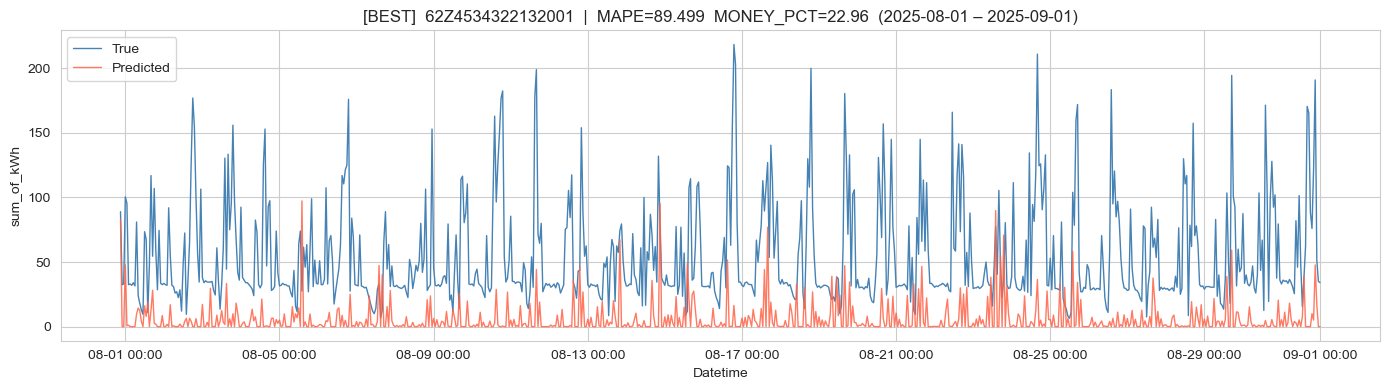

Worst station (MONEY_PCT): 62Z2673921373211


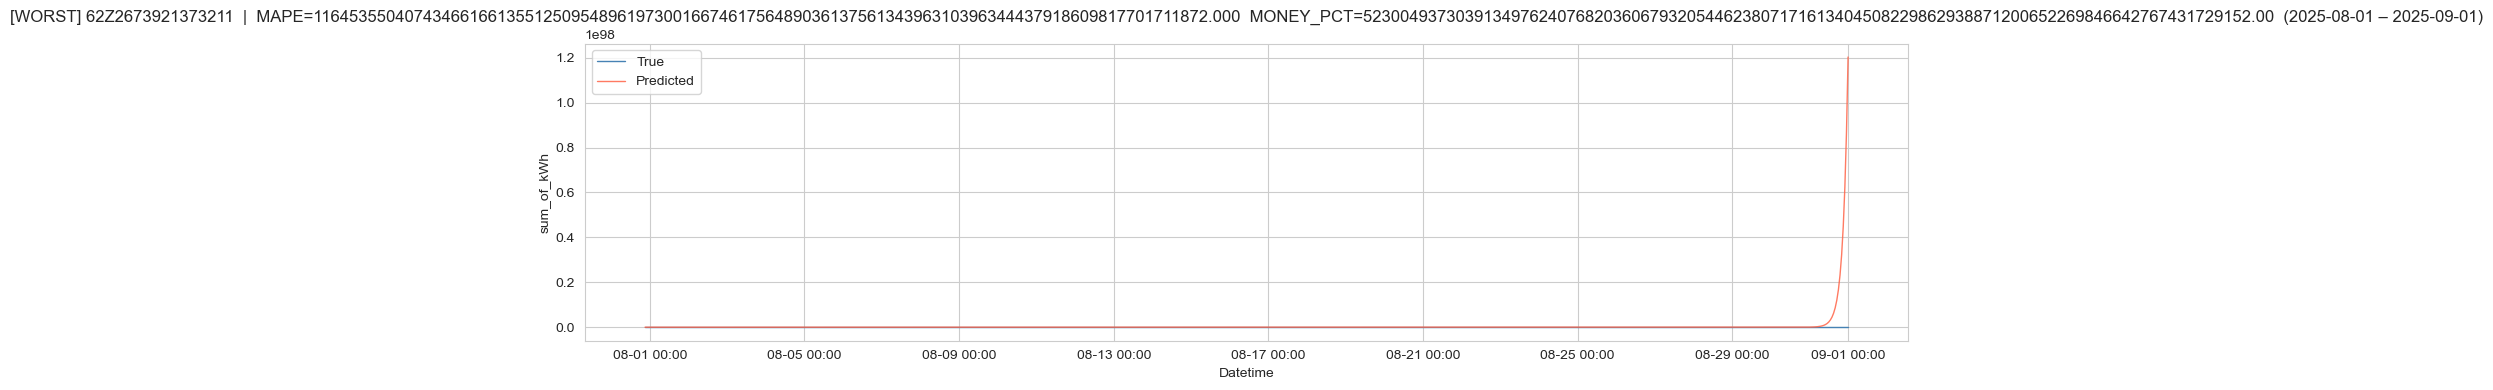

In [15]:
best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]

print(f"Best  station (MONEY_PCT): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")

print(f"Worst station (MONEY_PCT): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")